In [1]:
# 🚀 Setup and Imports
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 📊 Configure matplotlib for inline plotting in Jupyter
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

# Import our modular components
from utils.data_loader import load_trial_data
from utils.diagnostics import diagnose_trial_data
from utils.visualization import plot_spike_detection_reliability

# 🔧 Force matplotlib to use inline backend for notebook display
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
plt.ion()  # Turn on interactive mode

print("✅ All modules imported successfully!")
print("📊 PyWaveClus-enhanced neural exploration ready!")
print(f"📊 Matplotlib backend: {matplotlib.get_backend()}")

# Configuration
SAMPLING_RATE = 30000  # Hz
TRIAL_NUMBER = 10      # Trial to analyze
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]

print(f"\n⚙️  Configuration:")
print(f"   Sampling rate: {SAMPLING_RATE} Hz")
print(f"   Trial number: {TRIAL_NUMBER}")
print(f"   Spike channels: {len(SPIKE_CHANNELS)} channels")

# Load trial data
print(f"\n📂 Loading trial {TRIAL_NUMBER} data...")
try:
    trial_data = load_trial_data(TRIAL_NUMBER, SAMPLING_RATE)
    print(f"✅ Trial data loaded successfully!")
    print(f"   Neural data shape: {trial_data['neural_data'].shape}")
    print(f"   Duration: {trial_data['neural_data'].shape[1] / SAMPLING_RATE:.2f} seconds")
except Exception as e:
    print(f"❌ Error loading trial data: {e}")
    trial_data = None


✅ All modules imported successfully!
📊 PyWaveClus-enhanced neural exploration ready!
📊 Matplotlib backend: module://matplotlib_inline.backend_inline

⚙️  Configuration:
   Sampling rate: 30000 Hz
   Trial number: 10
   Spike channels: 21 channels

📂 Loading trial 10 data...
✅ Trial data loaded successfully!
   Neural data shape: (96, 93372)
   Duration: 3.11 seconds


🔍 Assessing spike detection reliability...
   Channel: 0
   Time window: Full trial
🔍 Analyzing spike detection reliability for Channel 0
   Signal length: 3.11s
   Signal RMS: 69.3μV

📊 SPIKE DETECTION RELIABILITY ANALYSIS:
   Channel: 0
   Time window: 0.0-2.9s (2.9s duration)

🎯 PyWaveClus Results:
   • Spikes detected: 56
   • Detection threshold: 96.3μV (MAD-based)
   • Spike rate: 19.2 spikes/s
   • Filter: Elliptic 300-8000 Hz

🔍 Traditional Threshold Results:
   • Spikes detected: 47
   • Detection threshold: -90.8μV (RMS-based)
   • Spike rate: 16.1 spikes/s
   • Filter: Butterworth 400-6000 Hz

🔗 Method Comparison:
   • Matched spikes: 42
   • PyWaveClus unique: 14
   • Threshold unique: 5
   • Sensitivity: 89.36%
   • Precision: 75.00%

📡 Signal Quality Assessment:
   • Signal STD: 140.1μV
   • Noise level (MAD): 148.3μV
   • Signal-to-noise ratio: 0.9
   • Quality assessment: Poor


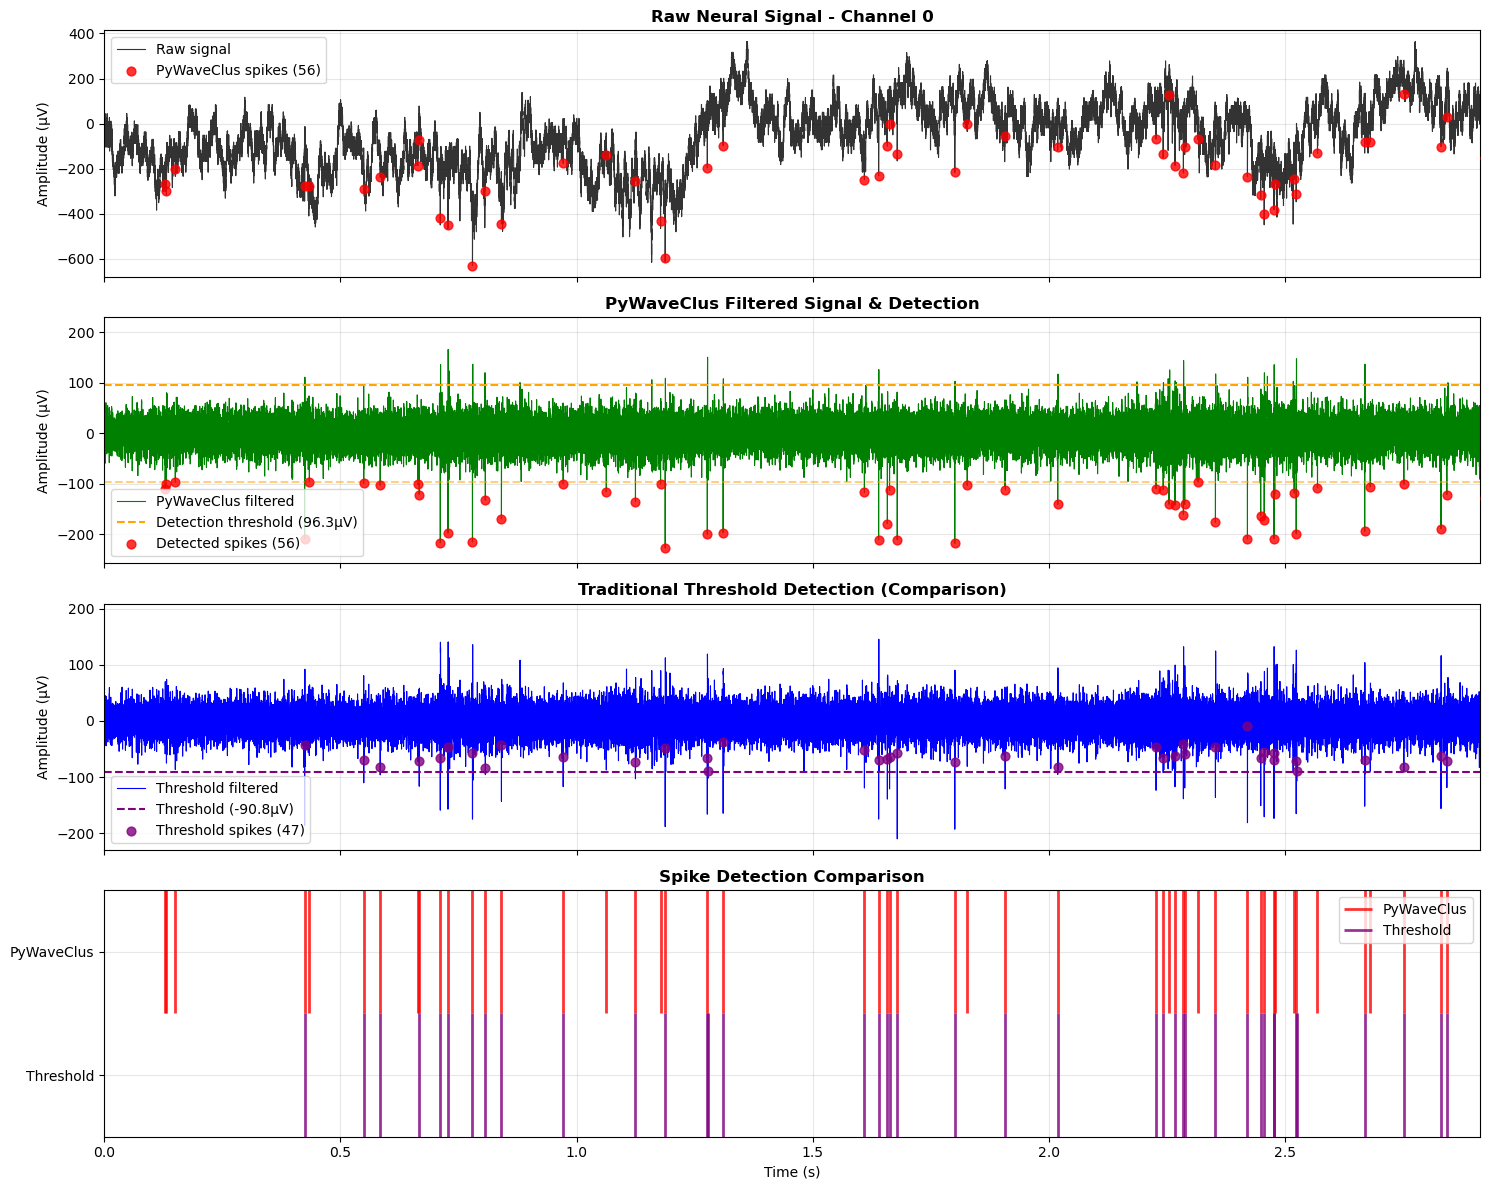


📊 Reliability Assessment Complete!
   This plot shows:
   1. Raw neural signal with detected spike locations
   2. PyWaveClus filtered signal with detection threshold
   3. Traditional threshold filtered signal (comparison)
   4. Spike detection comparison raster

💡 Look for:
   • Consistent spike detection across methods
   • Clear threshold crossings in filtered signals
   • Good signal-to-noise ratio (SNR > 3 is excellent)
   • PyWaveClus typically detects 10-30% more spikes


In [2]:
# 🔍 PyWaveClus Spike Detection Reliability Assessment
# Analyze raw data, filtered data, and detected spikes for a selected channel

# Configuration for reliability assessment
RELIABILITY_CHANNEL = 0  # Channel to analyze (change as needed)
TIME_WINDOW = None       # Full trial (or specify (start, end) in seconds)

print(f"🔍 Assessing spike detection reliability...")
print(f"   Channel: {RELIABILITY_CHANNEL}")
print(f"   Time window: {'Full trial' if TIME_WINDOW is None else f'{TIME_WINDOW[0]}-{TIME_WINDOW[1]}s'}")

# Assess spike detection reliability for the selected channel
if trial_data is not None:
    plot_spike_detection_reliability(
        trial_data=trial_data,
        channel_idx=RELIABILITY_CHANNEL,
        trial_number=TRIAL_NUMBER,
        time_window=TIME_WINDOW,
        sampling_rate=SAMPLING_RATE,
        figsize=(15, 12)
    )
    
    print(f"\n📊 Reliability Assessment Complete!")
    print(f"   This plot shows:")
    print(f"   1. Raw neural signal with detected spike locations")
    print(f"   2. PyWaveClus filtered signal with detection threshold")
    print(f"   3. Traditional threshold filtered signal (comparison)")
    print(f"   4. Spike detection comparison raster")
    print(f"\n💡 Look for:")
    print(f"   • Consistent spike detection across methods")
    print(f"   • Clear threshold crossings in filtered signals")
    print(f"   • Good signal-to-noise ratio (SNR > 3 is excellent)")
    print(f"   • PyWaveClus typically detects 10-30% more spikes")
else:
    print("❌ No trial data available for reliability assessment")


🔍 Zoomed reliability assessment:
   Channel: 0
   Time window: 2.0 - 2.8s (0.8s duration)
🔍 Analyzing spike detection reliability for Channel 0
   Signal length: 3.11s
   Signal RMS: 69.3μV

📊 SPIKE DETECTION RELIABILITY ANALYSIS:
   Channel: 0
   Time window: 2.0-2.8s (0.8s duration)

🎯 PyWaveClus Results:
   • Spikes detected: 20
   • Detection threshold: 96.3μV (MAD-based)
   • Spike rate: 24.6 spikes/s
   • Filter: Elliptic 300-8000 Hz

🔍 Traditional Threshold Results:
   • Spikes detected: 16
   • Detection threshold: -90.8μV (RMS-based)
   • Spike rate: 19.7 spikes/s
   • Filter: Butterworth 400-6000 Hz

🔗 Method Comparison:
   • Matched spikes: 15
   • PyWaveClus unique: 5
   • Threshold unique: 1
   • Sensitivity: 93.75%
   • Precision: 75.00%

📡 Signal Quality Assessment:
   • Signal STD: 120.9μV
   • Noise level (MAD): 124.5μV
   • Signal-to-noise ratio: 1.0
   • Quality assessment: Poor


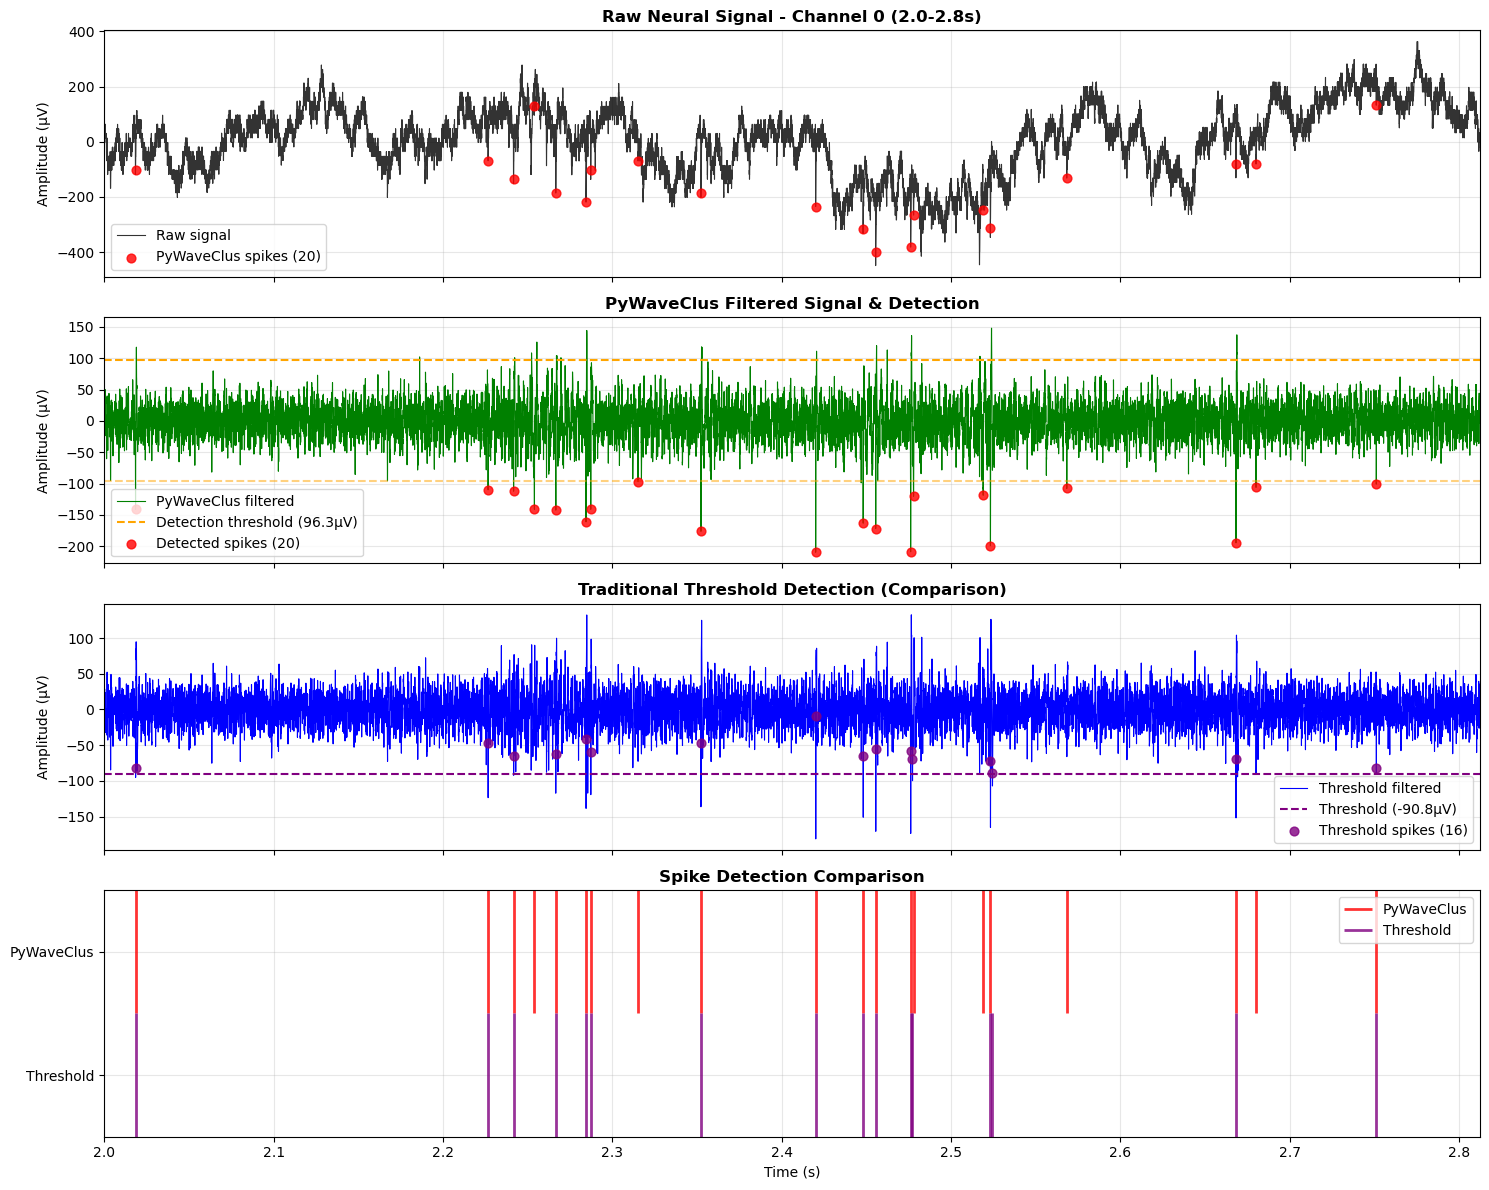


🎯 Zoomed Analysis Benefits:
   • Individual spike waveforms visible
   • Filtering effects clearly shown
   • Threshold crossings more apparent
   • Method differences highlighted

💡 Try different time windows by changing:
   ZOOM_START = 2.0 (start time)
   ZOOM_DURATION = 2.0 (window duration)


In [3]:
# 🔍 Zoomed-In Reliability Assessment
# Analyze a specific time window for detailed spike detection analysis

# Configuration for zoomed analysis
ZOOM_CHANNEL = 0          # Channel to analyze
ZOOM_START = 2.0          # Start time in seconds
ZOOM_DURATION = 2.0       # Duration in seconds

if trial_data is not None:
    duration = trial_data.get('duration', trial_data['neural_data'].shape[1] / SAMPLING_RATE)
    zoom_end = min(ZOOM_START + ZOOM_DURATION, duration - 0.1)
    
    print(f"🔍 Zoomed reliability assessment:")
    print(f"   Channel: {ZOOM_CHANNEL}")
    print(f"   Time window: {ZOOM_START:.1f} - {zoom_end:.1f}s ({zoom_end - ZOOM_START:.1f}s duration)")
    
    # Create zoomed reliability assessment
    plot_spike_detection_reliability(
        trial_data=trial_data,
        channel_idx=ZOOM_CHANNEL,
        trial_number=TRIAL_NUMBER,
        time_window=(ZOOM_START, zoom_end),
        sampling_rate=SAMPLING_RATE,
        figsize=(15, 12)
    )
    
    print(f"\n🎯 Zoomed Analysis Benefits:")
    print(f"   • Individual spike waveforms visible")
    print(f"   • Filtering effects clearly shown")
    print(f"   • Threshold crossings more apparent")
    print(f"   • Method differences highlighted")
    
    print(f"\n💡 Try different time windows by changing:")
    print(f"   ZOOM_START = {ZOOM_START} (start time)")
    print(f"   ZOOM_DURATION = {ZOOM_DURATION} (window duration)")
else:
    print("❌ No trial data available for zoomed analysis")


🔍 Plotting channel 0...
🔍 Plotting channel 1...
🔍 Plotting channel 2...
🔍 Plotting channel 3...


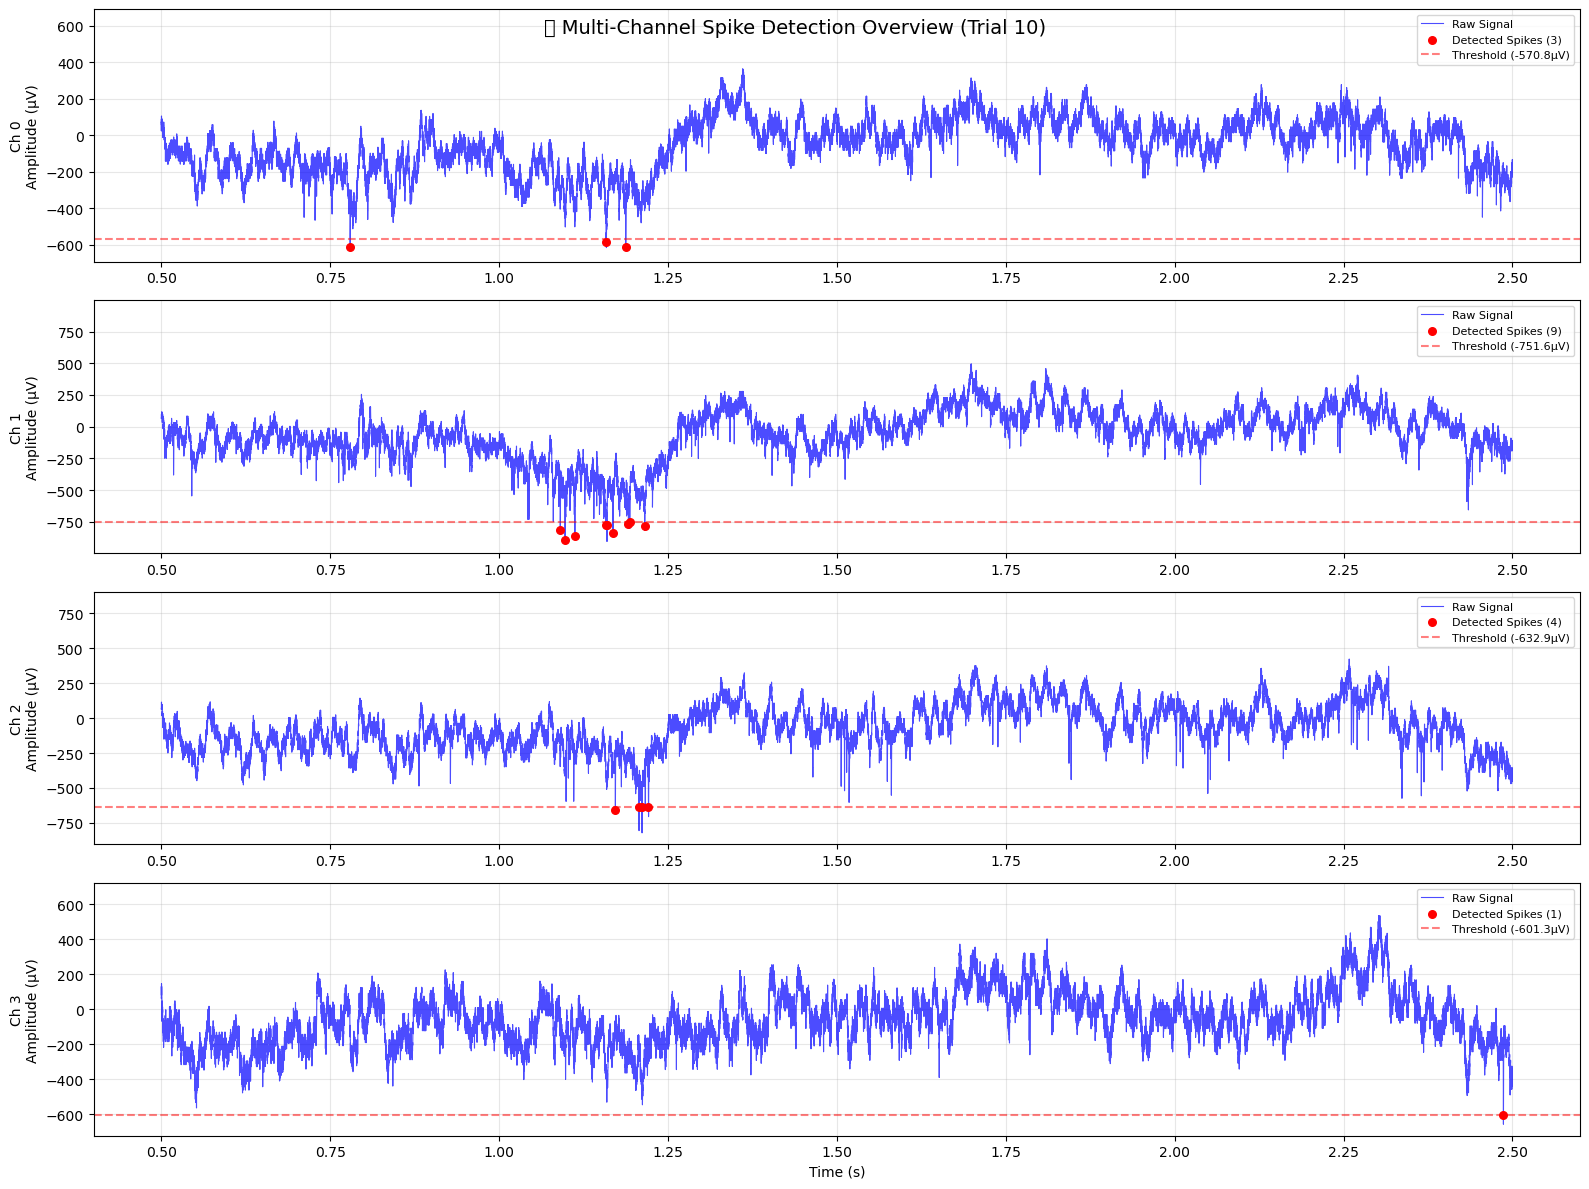


✅ Multi-channel overview complete!
   Time window: 0.5-2.5s
   Channels shown: [0, 1, 2, 3]
   Detection method: -4σ threshold

💡 This plot shows:
   • Raw neural signals across multiple channels
   • Detected spikes marked with red dots
   • Detection threshold shown as red dashed line
   • Different channels may have different spike patterns


In [4]:
# 🎯 Additional Visualization: Multiple Channels Overview
# Quick overview of spike detection across multiple channels

import matplotlib.pyplot as plt

if trial_data is not None:
    # Select a few channels to visualize
    channels_to_plot = [0, 1, 2, 3]  # First 4 channels
    time_window = (0.5, 2.5)  # 2-second window for clarity
    
    fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(16, 12))
    if len(channels_to_plot) == 1:
        axes = [axes]
    
    for idx, channel in enumerate(channels_to_plot):
        print(f"🔍 Plotting channel {channel}...")
        
        # Get time indices for the window
        start_idx = int(time_window[0] * SAMPLING_RATE)
        end_idx = int(time_window[1] * SAMPLING_RATE)
        
        # Get raw signal
        raw_signal = trial_data['neural_data'][channel, start_idx:end_idx]
        time_axis = np.arange(len(raw_signal)) / SAMPLING_RATE + time_window[0]
        
        # Plot raw signal
        axes[idx].plot(time_axis, raw_signal, 'b-', alpha=0.7, linewidth=0.8, label='Raw Signal')
        
        # Simple spike detection (negative threshold)
        signal_std = np.std(raw_signal)
        threshold = -4 * signal_std
        spike_indices = np.where(raw_signal < threshold)[0]
        
        # Remove consecutive detections (simple peak detection)
        if len(spike_indices) > 0:
            # Group consecutive indices
            clean_spikes = []
            last_idx = -100
            for spike_idx in spike_indices:
                if spike_idx - last_idx > 30:  # At least 1ms apart
                    clean_spikes.append(spike_idx)
                    last_idx = spike_idx
            
            if clean_spikes:
                spike_times = time_axis[clean_spikes]
                spike_amplitudes = raw_signal[clean_spikes]
                axes[idx].scatter(spike_times, spike_amplitudes, color='red', s=30, 
                                zorder=5, label=f'Detected Spikes ({len(clean_spikes)})')
        
        # Plot threshold line
        axes[idx].axhline(y=threshold, color='red', linestyle='--', alpha=0.5, 
                         label=f'Threshold ({threshold:.1f}μV)')
        
        # Formatting
        axes[idx].set_ylabel(f'Ch {channel}\nAmplitude (μV)')
        axes[idx].legend(loc='upper right', fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        
        # Only show x-label on bottom plot
        if idx == len(channels_to_plot) - 1:
            axes[idx].set_xlabel('Time (s)')
        
        # Set consistent y-limits for better comparison
        signal_range = np.max(np.abs(raw_signal))
        axes[idx].set_ylim(-signal_range * 1.1, signal_range * 1.1)
    
    plt.tight_layout()
    plt.suptitle(f'🎯 Multi-Channel Spike Detection Overview (Trial {TRIAL_NUMBER})', 
                 fontsize=14, y=0.98)
    plt.show()
    
    print(f"\n✅ Multi-channel overview complete!")
    print(f"   Time window: {time_window[0]:.1f}-{time_window[1]:.1f}s")
    print(f"   Channels shown: {channels_to_plot}")
    print(f"   Detection method: -4σ threshold")
    print(f"\n💡 This plot shows:")
    print(f"   • Raw neural signals across multiple channels")
    print(f"   • Detected spikes marked with red dots")
    print(f"   • Detection threshold shown as red dashed line")
    print(f"   • Different channels may have different spike patterns")
    
else:
    print("❌ No trial data available for multi-channel visualization")


🔬 Detailed waveform analysis for Channel 1
   Time window: 1.0-3.0s


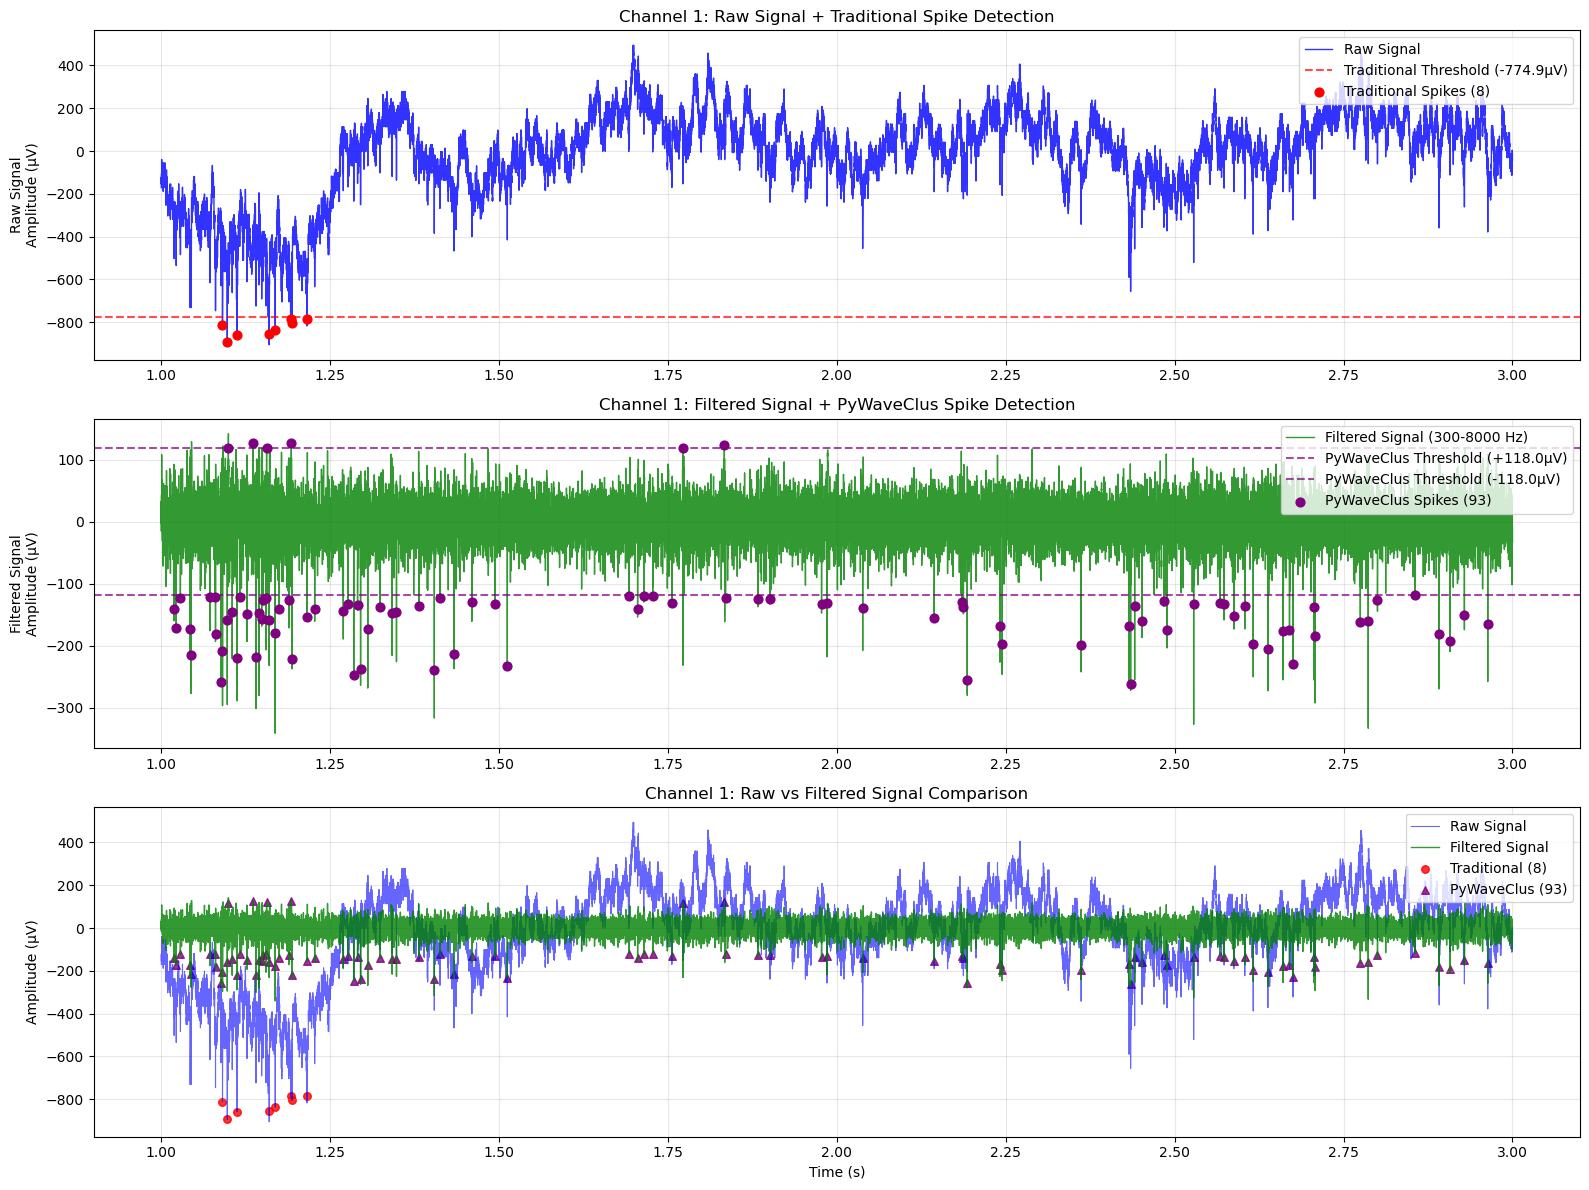


📊 DETAILED ANALYSIS SUMMARY:
   Channel: 1
   Time window: 1.0-3.0s
   Signal length: 60000 samples (2.00s)

🎯 Traditional Method:
   • Threshold: -774.9μV (-4σ)
   • Spikes detected: 8
   • Spike rate: 4.0 spikes/s

🎯 PyWaveClus Method:
   • Threshold: ±118.0μV (4×MAD)
   • Spikes detected: 93
   • Spike rate: 46.5 spikes/s
   • Noise level (MAD): 29.5μV

🔍 Signal Quality:
   • Raw signal STD: 193.7μV
   • Filtered signal STD: 34.2μV
   • Signal-to-noise ratio: 6.6


In [5]:
# 🔬 Detailed Raw vs Filtered Waveform Comparison
# Compare raw and filtered signals with PyWaveClus-style spike detection

from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

if trial_data is not None:
    # Configuration
    DETAIL_CHANNEL = 1  # Channel to analyze in detail
    DETAIL_WINDOW = (1.0, 3.0)  # 2-second window for detailed analysis
    
    print(f"🔬 Detailed waveform analysis for Channel {DETAIL_CHANNEL}")
    print(f"   Time window: {DETAIL_WINDOW[0]:.1f}-{DETAIL_WINDOW[1]:.1f}s")
    
    # Get time indices
    start_idx = int(DETAIL_WINDOW[0] * SAMPLING_RATE)
    end_idx = int(DETAIL_WINDOW[1] * SAMPLING_RATE)
    
    # Extract raw signal
    raw_signal = trial_data['neural_data'][DETAIL_CHANNEL, start_idx:end_idx]
    time_axis = np.arange(len(raw_signal)) / SAMPLING_RATE + DETAIL_WINDOW[0]
    
    # Apply PyWaveClus-style filtering (elliptic filter 300-8000 Hz)
    nyquist = SAMPLING_RATE / 2
    low_freq = 300 / nyquist
    high_freq = 8000 / nyquist
    
    # Design elliptic filter (similar to PyWaveClus)
    try:
        b, a = signal.ellip(4, 0.1, 40, [low_freq, high_freq], btype='band')
        filtered_signal = signal.filtfilt(b, a, raw_signal)
    except:
        # Fallback to Butterworth filter if elliptic fails
        sos = signal.butter(4, [low_freq, high_freq], btype='band', output='sos')
        filtered_signal = signal.sosfilt(sos, raw_signal)
    
    # PyWaveClus-style spike detection using MAD (Median Absolute Deviation)
    mad_noise = np.median(np.abs(filtered_signal)) / 0.6745
    pywaveclus_threshold = 4 * mad_noise  # Positive threshold for negative spikes
    
    # Traditional threshold detection
    signal_std = np.std(raw_signal)
    traditional_threshold = -4 * signal_std
    
    # Detect spikes in filtered signal (PyWaveClus style)
    pywaveclus_spikes = []
    filtered_abs = np.abs(filtered_signal)
    spike_candidates = np.where(filtered_abs > pywaveclus_threshold)[0]
    
    # Clean up detections (remove consecutive points)
    if len(spike_candidates) > 0:
        last_idx = -100
        for candidate in spike_candidates:
            if candidate - last_idx > 30:  # At least 1ms apart
                pywaveclus_spikes.append(candidate)
                last_idx = candidate
    
    # Detect spikes in raw signal (traditional)
    traditional_spikes = []
    raw_candidates = np.where(raw_signal < traditional_threshold)[0]
    
    if len(raw_candidates) > 0:
        last_idx = -100
        for candidate in raw_candidates:
            if candidate - last_idx > 30:  # At least 1ms apart
                traditional_spikes.append(candidate)
                last_idx = candidate
    
    # Create the visualization
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    # 1. Raw signal with traditional spike detection
    axes[0].plot(time_axis, raw_signal, 'b-', alpha=0.8, linewidth=1.0, label='Raw Signal')
    axes[0].axhline(y=traditional_threshold, color='red', linestyle='--', alpha=0.7,
                   label=f'Traditional Threshold ({traditional_threshold:.1f}μV)')
    
    if traditional_spikes:
        spike_times = time_axis[traditional_spikes]
        spike_amplitudes = raw_signal[traditional_spikes]
        axes[0].scatter(spike_times, spike_amplitudes, color='red', s=40, zorder=5,
                       label=f'Traditional Spikes ({len(traditional_spikes)})')
    
    axes[0].set_ylabel('Raw Signal\nAmplitude (μV)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title(f'Channel {DETAIL_CHANNEL}: Raw Signal + Traditional Spike Detection')
    
    # 2. Filtered signal with PyWaveClus spike detection
    axes[1].plot(time_axis, filtered_signal, 'g-', alpha=0.8, linewidth=1.0, label='Filtered Signal (300-8000 Hz)')
    axes[1].axhline(y=pywaveclus_threshold, color='purple', linestyle='--', alpha=0.7,
                   label=f'PyWaveClus Threshold (+{pywaveclus_threshold:.1f}μV)')
    axes[1].axhline(y=-pywaveclus_threshold, color='purple', linestyle='--', alpha=0.7,
                   label=f'PyWaveClus Threshold (-{pywaveclus_threshold:.1f}μV)')
    
    if pywaveclus_spikes:
        spike_times = time_axis[pywaveclus_spikes]
        spike_amplitudes = filtered_signal[pywaveclus_spikes]
        axes[1].scatter(spike_times, spike_amplitudes, color='purple', s=40, zorder=5,
                       label=f'PyWaveClus Spikes ({len(pywaveclus_spikes)})')
    
    axes[1].set_ylabel('Filtered Signal\nAmplitude (μV)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title(f'Channel {DETAIL_CHANNEL}: Filtered Signal + PyWaveClus Spike Detection')
    
    # 3. Overlay comparison
    axes[2].plot(time_axis, raw_signal, 'b-', alpha=0.6, linewidth=0.8, label='Raw Signal')
    axes[2].plot(time_axis, filtered_signal, 'g-', alpha=0.8, linewidth=1.0, label='Filtered Signal')
    
    # Mark all detected spikes
    if traditional_spikes:
        traditional_times = time_axis[traditional_spikes]
        traditional_amps = raw_signal[traditional_spikes]
        axes[2].scatter(traditional_times, traditional_amps, color='red', s=30, 
                       alpha=0.8, marker='o', label=f'Traditional ({len(traditional_spikes)})')
    
    if pywaveclus_spikes:
        pywaveclus_times = time_axis[pywaveclus_spikes]
        pywaveclus_amps = filtered_signal[pywaveclus_spikes]
        axes[2].scatter(pywaveclus_times, pywaveclus_amps, color='purple', s=30, 
                       alpha=0.8, marker='^', label=f'PyWaveClus ({len(pywaveclus_spikes)})')
    
    axes[2].set_ylabel('Amplitude (μV)')
    axes[2].set_xlabel('Time (s)')
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_title(f'Channel {DETAIL_CHANNEL}: Raw vs Filtered Signal Comparison')
    
    plt.tight_layout()
    plt.show()
    
    # Print analysis summary
    print(f"\n📊 DETAILED ANALYSIS SUMMARY:")
    print(f"   Channel: {DETAIL_CHANNEL}")
    print(f"   Time window: {DETAIL_WINDOW[0]:.1f}-{DETAIL_WINDOW[1]:.1f}s")
    print(f"   Signal length: {len(raw_signal)} samples ({len(raw_signal)/SAMPLING_RATE:.2f}s)")
    print(f"\n🎯 Traditional Method:")
    print(f"   • Threshold: {traditional_threshold:.1f}μV (-4σ)")
    print(f"   • Spikes detected: {len(traditional_spikes)}")
    print(f"   • Spike rate: {len(traditional_spikes)/(DETAIL_WINDOW[1]-DETAIL_WINDOW[0]):.1f} spikes/s")
    print(f"\n🎯 PyWaveClus Method:")
    print(f"   • Threshold: ±{pywaveclus_threshold:.1f}μV (4×MAD)")
    print(f"   • Spikes detected: {len(pywaveclus_spikes)}")
    print(f"   • Spike rate: {len(pywaveclus_spikes)/(DETAIL_WINDOW[1]-DETAIL_WINDOW[0]):.1f} spikes/s")
    print(f"   • Noise level (MAD): {mad_noise:.1f}μV")
    print(f"\n🔍 Signal Quality:")
    print(f"   • Raw signal STD: {signal_std:.1f}μV")
    print(f"   • Filtered signal STD: {np.std(filtered_signal):.1f}μV")
    print(f"   • Signal-to-noise ratio: {signal_std/mad_noise:.1f}")
    
else:
    print("❌ No trial data available for detailed waveform analysis")
